# Testing the AI with My Handwriting
In this notebook, we are going to load our trained AI model and ask it to read a number I drew myself. 

First, we import our tools. We are using `PIL` (Python Imaging Library) to open the image file.

In [1]:
import tensorflow as tf
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

Now we need to process our drawing. The AI was trained on a very specific type of image, so we have to make our drawing match that format before the AI can look at it.

1. Convert it to grayscale (black and white only).
2. Invert the colors. We drew black text on a white background, but the AI learned from white text on a black background.
3. Shrink it down to exactly 28x28 pixels.
4. Squish the pixel values down to a scale between 0 and 1.

We will also draw the processed image on the screen so we can see exactly what the AI is seeing.

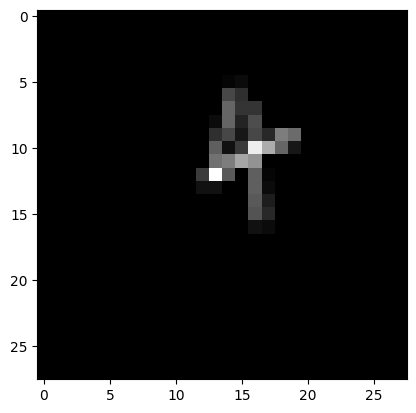

In [2]:
img = Image.open('my_digit.png')

img = img.convert('L')
img = ImageOps.invert(img)
img = img.resize((28, 28))

img_array = np.array(img) / 255.0

plt.imshow(img_array, cmap='gray')
plt.show()

Finally, we load the brain we saved earlier (`mnist_model.keras`). 

We wrap our single image inside another array because the AI is expecting a "batch" or list of images, even if it is a list of just one. Then, we ask for a prediction and print the highest probability result!

In [3]:
model = tf.keras.models.load_model('mnist_model.keras')

img_array = img_array.reshape(1, 28, 28)

prediction = model.predict(img_array)
predicted_number = np.argmax(prediction)

print(f"The AI thinks this number is: {predicted_number}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
The AI thinks this number is: 5
